# Practica 6 - Data classification (Entrega en semana 10)
   Create a model using k nearest neighbor and test it.

La siguiente practica hace uso del Knn (K nearest Neighbor) para predecir la clasificacion de un dato. 

En el caso de este ejemplo, lo usaremos para predecir a que consola pertenece un juego solamente conociendo las ventas norteamericanas y japonesas del mismo, dadas en forma de un punto (x,y).

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("../datasets/vgsales_clean.csv")
data.head()

,Nombre,Plataforma,Año,Género,Publicador,Ventas_Norteamérica,Ventas_Europa,Ventas_Japón,Ventas_Otros,Ventas_Globales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Las siguientes son las plataformas en las cuales el juego puede pertenecer:

In [69]:
plataformas = data['Plataforma'].unique()
print(plataformas)

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'GC' 'WiiU' 'GEN' 'XOne' 'DC' 'SAT' 'PSV'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


El siguiente plot lo usamos como ayuda visual, para ver la distribucion de las ventas norteamericas y japoneas (x,y) segun su consola.

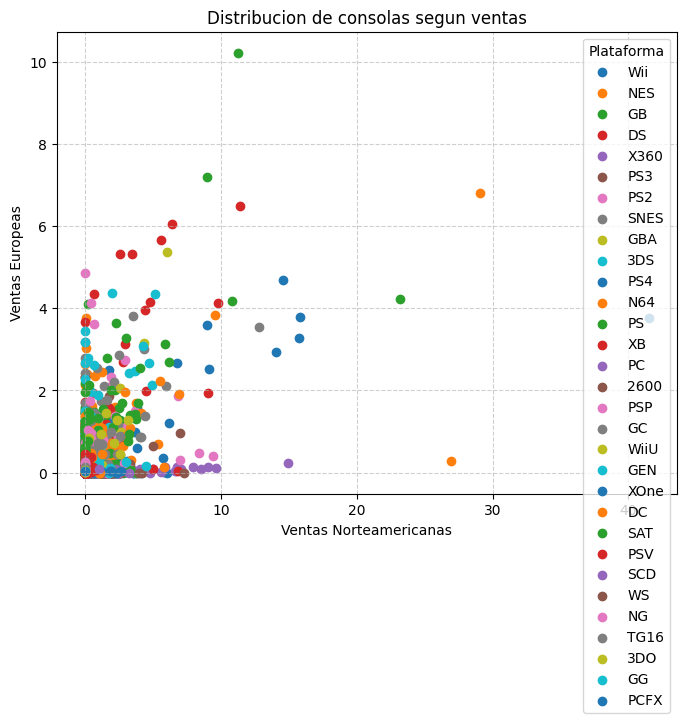

In [74]:
fig, ax = plt.subplots(figsize=(8, 6))
for plataforma in plataformas:
    subset = data[data['Plataforma'] == plataforma]

    ax.scatter(
        subset['Ventas_Norteamérica'],
        subset['Ventas_Japón'],
        label=plataforma
    )

ax.legend(title='Plataforma')
ax.set_title('Distribucion de consolas segun ventas')
ax.set_xlabel('Ventas Norteamericanas')
ax.set_ylabel('Ventas Europeas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Uso de KNN
En el siguiente parte del codigo hacemos uso de KNN, para despues plottear el resultado en una grafica donde se encuentra el punto que agregamos. 

Tomando en cuenta las ventas del norteamericanas y japonesas del juego proporcionado, es mas probable que sea de la consola: Wii


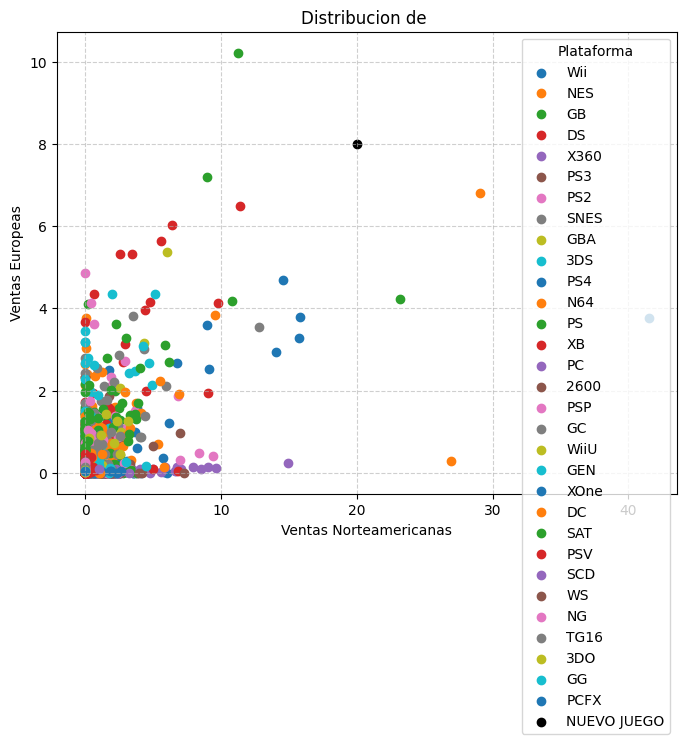

In [79]:
def distancia_euclidiana(punto1, punto2):
    """Retorna la distancia entre dos puntos (x,y) dados"""
    distance = 0
    for i in range(len(punto1)):
        distance += (punto2[i] - punto1[i])**2
    return math.sqrt(distance)

def knn(data, punto, k):
    """Usa el algortimo de k-nearest neighbors para predecir la clasificacion del nuevo dato"""

    distances = []
    for index in range(len(data)):
        punto2 = np.array(data.loc[index][['Ventas_Norteamérica','Ventas_Japón']])
        dist =  distancia_euclidiana(punto, punto2)
        distances.append((data.loc[index]["Plataforma"], dist))

    distances.sort(key=lambda x: x[1])

    vecinos = []
    for i in range(k):
        vecinos.append(distances[i][0])

    prediccion = max(vecinos)

    print(f'Tomando en cuenta las ventas del norteamericanas y japonesas del juego proporcionado, es mas probable que sea de la consola: {prediccion}')


#------------ COORDENADA DEL NUEVO JUEGO (Ventas norteamericanas, ventas japonesas) y numero de vecinos
punto = [20,8]
vecinos = 3


#------------ USO DE KNN ---------------------------
knn(data, punto, vecinos)


#----------- GRAFICA DE LA RESPUESTA -------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
for plataforma in plataformas:
    subset = data[data['Plataforma'] == plataforma]

    ax.scatter(
        subset['Ventas_Norteamérica'],
        subset['Ventas_Japón'],
        label=plataforma
    )
ax.scatter(punto[0],punto[1], c='black', label="NUEVO JUEGO")

ax.legend(title='Plataforma')
ax.set_title('Distribucion de ')
ax.set_xlabel('Ventas Norteamericanas')
ax.set_ylabel('Ventas Europeas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()